In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv
/kaggle/input/datasets/organizations/uciml/human-activity-recognition-with-smartphones/train.csv
/kaggle/input/datasets/organizations/uciml/human-activity-recognition-with-smartphones/test.csv


In [3]:
for root, dirs, files in os.walk('/kaggle/input'):
    print(root)
    print(files)
    print('----------------')

/kaggle/input
[]
----------------
/kaggle/input/competitions
[]
----------------
/kaggle/input/competitions/titanic
['train.csv', 'test.csv', 'gender_submission.csv']
----------------
/kaggle/input/datasets
[]
----------------
/kaggle/input/datasets/organizations
[]
----------------
/kaggle/input/datasets/organizations/uciml
[]
----------------
/kaggle/input/datasets/organizations/uciml/human-activity-recognition-with-smartphones
['train.csv', 'test.csv']
----------------


In [4]:
df = pd.read_csv(
    '/kaggle/input/datasets/organizations/uciml/human-activity-recognition-with-smartphones/train.csv'
)

df['subject'].head(10)

0    1
1    1
2    1
3    1
4    1
5    1
6    1
7    1
8    1
9    1
Name: subject, dtype: int64

In [5]:
df = pd.read_csv(
    '/kaggle/input/datasets/organizations/uciml/human-activity-recognition-with-smartphones/train.csv'
)

df = df.drop(columns='subject')

df.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,STANDING


In [34]:
df['Activity'].value_counts()

Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64

In [6]:
print(df.shape)

(7352, 562)


***1.Remove Duplicate Columns***

In [10]:
duplicate_cols = df.columns[df.T.duplicated()]

print("Duplicate columns:")
print(duplicate_cols)

print("\nTotal duplicate columns:", len(duplicate_cols))
df = df.loc[:, ~df.T.duplicated()]

Duplicate columns:
Index(['tBodyAccMag-sma()', 'tGravityAccMag-mean()', 'tGravityAccMag-std()',
       'tGravityAccMag-mad()', 'tGravityAccMag-max()', 'tGravityAccMag-min()',
       'tGravityAccMag-sma()', 'tGravityAccMag-energy()',
       'tGravityAccMag-iqr()', 'tGravityAccMag-entropy()',
       'tGravityAccMag-arCoeff()1', 'tGravityAccMag-arCoeff()2',
       'tGravityAccMag-arCoeff()3', 'tGravityAccMag-arCoeff()4',
       'tBodyAccJerkMag-sma()', 'tBodyGyroMag-sma()', 'tBodyGyroJerkMag-sma()',
       'fBodyAccMag-sma()', 'fBodyBodyAccJerkMag-sma()',
       'fBodyBodyGyroMag-sma()', 'fBodyBodyGyroJerkMag-sma()'],
      dtype='object')

Total duplicate columns: 21


In [11]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Separate features and target
X = df.drop('Activity', axis=1)
y = df['Activity']

# Encode target labels
le = LabelEncoder()
y = le.fit_transform(y)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [12]:
print(X_train.shape)
print(X_test.shape)

(5881, 540)
(1471, 540)


In [13]:
# Initialize and train logistic regression model
log_reg = LogisticRegression(max_iter=1000)  # Increase max_iter if it doesn't converge
log_reg.fit(X_train, y_train)

# Make predictions on the test set
y_pred = log_reg.predict(X_test)

# Calculate and print accuracy score
accuracy = accuracy_score(y_test, y_pred)
print("Test accuracy:", accuracy)

Test accuracy: 0.9850441876274643


***2.Variance Threshold***

In [14]:
from sklearn.feature_selection import VarianceThreshold
sel = VarianceThreshold(threshold=0.05)
sel.fit(X_train)
X_train= sel.transform(X_train)
X_test= sel.transform(X_test)

In [15]:
print(X_train.shape)
print(X_test.shape)

(5881, 350)
(1471, 350)


***3.Correlation***

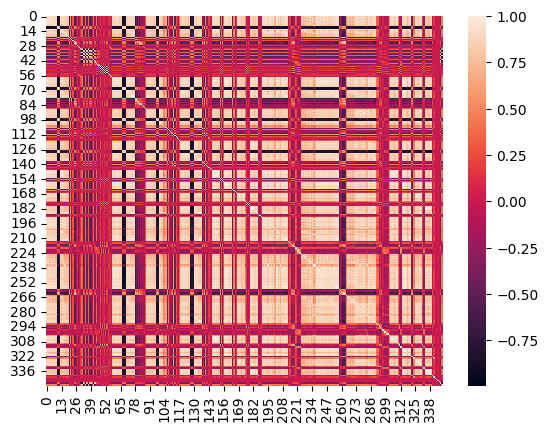

In [16]:
X_train = pd.DataFrame(X_train)
X_test = pd.DataFrame(X_test)
import seaborn as sns
sns.heatmap(X_train.corr())
corr_matrix = X_train.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]

X_train = X_train.drop(columns=to_drop)
X_test = X_test.drop(columns=to_drop)

In [17]:
print(X_train.shape)
print(X_test.shape)

(5881, 138)
(1471, 138)


***4.ANOVA***

In [18]:
from sklearn.feature_selection import SelectKBest, f_classif

# Keep top 100 important features
selector = SelectKBest(f_classif, k=100)

# Fit on training data and transform
X_train = selector.fit_transform(X_train, y_train)

# Transform test data
X_test = selector.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(5881, 100)
(1471, 100)


In [19]:
print(X_train.shape)
print(X_test.shape)

(5881, 100)
(1471, 100)


***6.Mutual Information***

In [21]:
from sklearn.feature_selection import mutual_info_classif
X_train = pd.DataFrame(X_train)
X_test = pd.DataFrame(X_test)

# Calculate MI scores
mi_scores = mutual_info_classif(X_train, y_train)

# Convert to Series
mi_scores = pd.Series(mi_scores, index=X_train.columns)

# Sort scores
mi_scores = mi_scores.sort_values(ascending=False)

print(mi_scores)

0     0.879018
17    0.867786
85    0.821148
65    0.812559
58    0.791713
        ...   
32    0.064931
50    0.064527
64    0.064348
11    0.057873
46    0.047171
Length: 100, dtype: float64


In [26]:
print(X_train.shape)
print(X_test.shape)

(5881, 99)
(1471, 99)


In [27]:
selected_features = mi_scores[mi_scores > 0.05]
selected_columns = selected_features.index

print(selected_columns)
print(selected_features)
X_train = X_train[selected_columns]
X_test = X_test[selected_columns]

Index([ 0, 17, 85, 65, 58, 39,  3, 40,  4, 86, 76, 38, 35, 28, 29, 77, 52, 74,
       75, 37, 93, 62, 36,  1, 61, 78,  5, 16, 67,  2, 20, 18,  6, 95,  7, 66,
       43, 81, 68,  8, 21, 79, 94, 88, 87, 48, 72, 42, 14, 41, 47, 69, 19, 83,
       82, 55, 12, 23, 51, 53, 59, 13, 84,  9, 63, 24, 22, 44, 49, 60, 15, 97,
       73, 45, 27, 80, 25, 96, 26, 71, 30, 70, 98, 90, 91, 92, 54, 33, 89, 56,
       57, 99, 10, 34, 31, 32, 50, 64, 11],
      dtype='int64')
0     0.879018
17    0.867786
85    0.821148
65    0.812559
58    0.791713
        ...   
31    0.073079
32    0.064931
50    0.064527
64    0.064348
11    0.057873
Length: 99, dtype: float64


In [25]:
# Initialize and train logistic regression model
log_reg = LogisticRegression(max_iter=1000)  # Increase max_iter if it doesn't converge
log_reg.fit(X_train, y_train)

# Make predictions on the test set
y_pred = log_reg.predict(X_test)

# Calculate and print accuracy score
accuracy = accuracy_score(y_test, y_pred)
print("Test accuracy:", accuracy)

Test accuracy: 0.9680489462950373


*****6.Chi-Square Test*****

In [28]:
import seaborn as sns

df = sns.load_dataset('titanic')

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [32]:
df = df[['sex', 'embarked', 'class',
         'who', 'adult_male',
         'alone', 'survived']]

In [34]:
df = df.dropna()

In [35]:
X = df.drop('survived', axis=1)
y = df['survived']

In [36]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X = X.apply(le.fit_transform)

In [37]:
from sklearn.feature_selection import chi2

chi_scores = chi2(X, y)

In [38]:
import pandas as pd
p_values = pd.Series(chi_scores[1], index=X.columns)

In [39]:
p_values.sort_values(inplace=True)

print(p_values)

adult_male    1.957663e-25
sex           1.108034e-21
class         3.151471e-13
who           1.988540e-07
alone         1.045610e-04
embarked      1.225432e-03
dtype: float64


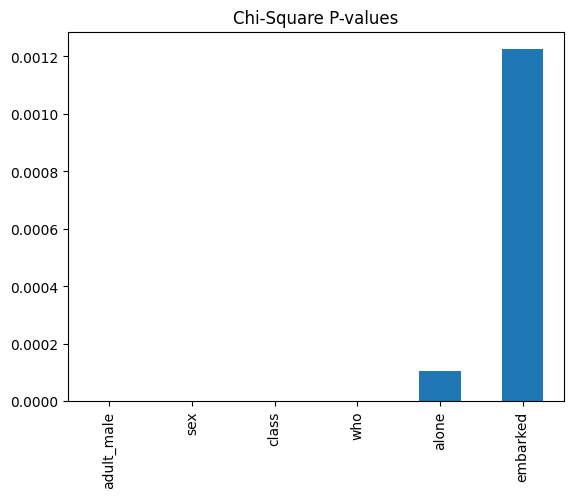

In [40]:
import matplotlib.pyplot as plt

p_values.plot.bar()

plt.title('Chi-Square P-values')

plt.show()

# Observation on Filter-Based Feature Selection Methods

Filter methods perform feature selection using statistical techniques before model training. These methods evaluate features independently of the machine learning model and are generally computationally faster than wrapper and embedded methods.

The following filter-based feature selection methods were applied:

1. Variance Threshold
2. Correlation-Based Feature Selection
3. ANOVA
4. Chi-Square Test
5. Mutual Information

---

## 1. Variance Threshold

Variance Threshold removes features with very low variance. Features that show little variation across observations usually contain very little useful information for prediction.

In the HAR dataset, low variance features were removed using a predefined variance threshold. This helped reduce dimensionality by eliminating nearly constant features while preserving most of the predictive information.

---

## 2. Correlation-Based Feature Selection

Correlation-based feature selection removes highly correlated features. Highly correlated features often carry redundant information and can increase multicollinearity.

A correlation threshold of:

* 0.95

was used. If two features had correlation greater than 0.95, one of them was removed.

This method significantly reduced feature redundancy and helped simplify the dataset without major loss in accuracy.

---

## 3. ANOVA (Analysis of Variance)

ANOVA was applied for supervised feature selection on numerical features with a categorical target variable.

ANOVA tests the hypothesis:

* Null Hypothesis ((H_0)):
  Mean values of the feature are equal across all classes.

* Alternative Hypothesis ((H_1)):
  At least one class mean differs significantly.

Features with high F-scores were considered important because their values differed significantly across target classes.

The method helped identify features that strongly separated different activity classes in the HAR dataset.

---

## 4. Chi-Square Test

Chi-Square feature selection was applied on categorical features using the Titanic dataset.

The Chi-Square test checks whether a feature and the target variable are statistically dependent.

* Null Hypothesis ((H_0)):
  Feature and target are independent.

* Alternative Hypothesis ((H_1)):
  Feature and target are dependent.

Features with small p-values were considered important because they showed strong association with the target variable.

This method worked well for identifying important categorical variables such as:

* Sex
* Passenger Class
* Embarked

for predicting survival.

---

## 5. Mutual Information

Mutual Information measures how much information a feature provides about the target variable.

Unlike correlation and ANOVA, Mutual Information can capture:

* linear relationships
* nonlinear relationships
* complex dependencies

Features with higher Mutual Information scores were considered more informative.

In the HAR dataset, applying Mutual Information reduced the feature count from:

* 562 features → 99 features

while maintaining model accuracy close to the original model.

The logistic regression accuracy reduced only slightly:

* from 0.98 → 0.96

showing that most predictive information was retained even after major dimensionality reduction.

---

## Overall Observation

Filter methods are:

* computationally efficient
* simple to implement
* suitable for high-dimensional datasets

They help remove:

* redundant features
* irrelevant features
* low-information variables

before model training.

However, filter methods evaluate features independently and may miss important feature interactions. Compared to wrapper and embedded methods, they are faster but sometimes less accurate.

The experiments demonstrated that a large reduction in feature dimensionality can often be achieved with only a small decrease in model accuracy.
